In [1]:
import pandas as pd
from matplotlib import pyplot as plt
plt.rc('font', family = 'Malgun Gothic')
import seaborn as sns
df = pd.read_csv(r"C:\Users\kicki\제로베이스파이썬\Excel_Practice\gender_classification_v7.csv")

In [2]:
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


In [5]:
# 분포확인 - 여기만 분포가 많이 차이난다. (그래서 남자 여자가 머리로 구분된다는걸 확인필요?)
df['long_hair'].value_counts(normalize = True)

long_hair
1    0.869626
0    0.130374
Name: proportion, dtype: float64

In [7]:
df['nose_wide'].value_counts(normalize = True)

nose_wide
0    0.506099
1    0.493901
Name: proportion, dtype: float64

In [8]:
df['nose_long'].value_counts(normalize = True)

nose_long
1    0.507898
0    0.492102
Name: proportion, dtype: float64

In [9]:
df['lips_thin'].value_counts(normalize = True)

lips_thin
0    0.506899
1    0.493101
Name: proportion, dtype: float64

In [10]:
df['distance_nose_to_lip_long'].value_counts(normalize = True)

distance_nose_to_lip_long
0    0.5011
1    0.4989
Name: proportion, dtype: float64

In [6]:
df['forehead_width_cm'].describe()
# 아래 데이터의 해석이 중요하다. 1) mean과 50%가 거의 동일. 중간을 기점으로 양쪽으로 펴저있다. 2) std가 1에 가깝다. 분포가 꽤 가깝게 정상분포일듯

count    5001.000000
mean       13.181484
std         1.107128
min        11.400000
25%        12.200000
50%        13.100000
75%        14.000000
max        15.500000
Name: forehead_width_cm, dtype: float64

In [11]:
df['forehead_height_cm'].describe()

count    5001.000000
mean        5.946311
std         0.541268
min         5.100000
25%         5.500000
50%         5.900000
75%         6.400000
max         7.100000
Name: forehead_height_cm, dtype: float64

In [12]:
def make_cross_table(col): #Col 기준으로 corss table 만들꺼야
    ct = pd.crosstab(df[col], df['gender']) # Coloumns(col)에서 gender column을 나열할꺼야
    ct['sum'] = ct.sum(axis = 1) # 열(의 합계)
    ct.loc['sum'] = ct.sum(axis = 0) # 행(의 합계)
    return ct

In [14]:
make_cross_table('long_hair') # 의외로 영향도가 없음 (위에 1차 가정 false)

gender,Female,Male,sum
long_hair,,,
0,317,335,652
1,2184,2165,4349
sum,2501,2500,5001


In [15]:
make_cross_table('nose_wide') # 넓으면 남자일 가능성 높다

gender,Female,Male,sum
nose_wide,,,
0,2214,317,2531
1,287,2183,2470
sum,2501,2500,5001


In [19]:
make_cross_table('nose_long') # 길면 남자일 가능성 높다

gender,Female,Male,sum
nose_long,,,
0,2161,300,2461
1,340,2200,2540
sum,2501,2500,5001


In [20]:
make_cross_table('lips_thin') # thin > 여자일 가능성 높다

gender,Female,Male,sum
lips_thin,,,
0,2197,338,2535
1,304,2162,2466
sum,2501,2500,5001


In [21]:
make_cross_table('distance_nose_to_lip_long') # nose ~ lip 거리가 길면 여자, 짧으면 남자가능성 높다 == 0일때 여자가능성 / 1 남자가능성

gender,Female,Male,sum
distance_nose_to_lip_long,,,
0,2197,309,2506
1,304,2191,2495
sum,2501,2500,5001


<Axes: xlabel='forehead_width_cm', ylabel='Density'>

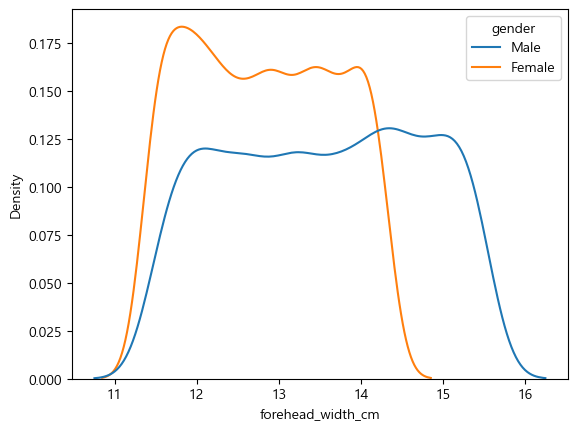

In [22]:
sns.kdeplot(df, x = 'forehead_width_cm', hue = 'gender') # 14.3cm 이상중에 여자는 없다

In [25]:
df.groupby('gender')['forehead_width_cm'].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
Female,2501.0,12.811675,0.876703,11.4,12.0,12.8,13.6,14.3
Male,2500.0,13.551440,1.187325,11.5,12.5,13.6,14.6,15.5


<Axes: xlabel='forehead_height_cm', ylabel='Density'>

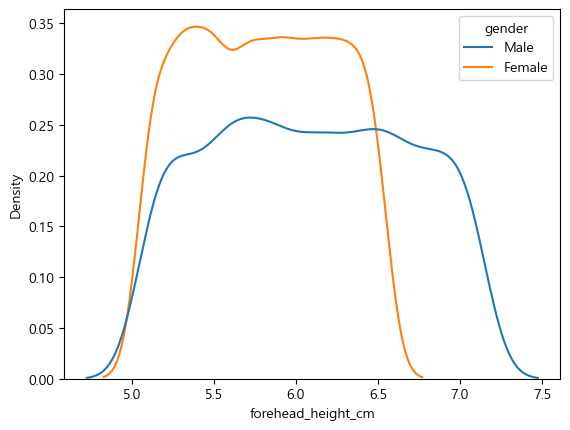

In [26]:
sns.kdeplot(df, x = 'forehead_height_cm', hue = 'gender')

In [28]:
df.groupby('gender')['forehead_height_cm'].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
Female,2501.0,5.796321,0.430677,5.1,5.4,5.8,6.2,6.5
Male,2500.0,6.096360,0.596306,5.1,5.6,6.1,6.6,7.1


In [30]:
# 변수 결합 = 코 관련 (위에 보면 코 관련내용으로 남자 여자 구분되는 경향이 있음) - WOW (cross table을 활용한 관련정보 연결하나 tabale하나로)
df['nose_var'] = df['nose_wide'].astype(str) + df['nose_long'].astype(str) + df['distance_nose_to_lip_long'].astype(str)
# 단순히 3개조건의 숫자를 더할수도 있으나, 나올수 있는 모든 변수를 다 확인하기위해서 str형태로 붙힌다 - re (1/11/2026) 
make_cross_table('nose_var')
# 하기에 있는 숫자는 0,1의 조합이다. 3개 조합이니 총 9개가 나온다
# 000의 의미는 - nose_wide = 0, nose_long = 0, distance = 0 > 이 조합은 여자라고 할수있을만큼 99% 수준으로 높다

gender,Female,Male,sum
nose_var,,,
000,1667,4,1671
001,236,45,281
010,274,35,309
011,37,233,270
100,231,31,262
101,27,220,247
110,25,239,264
111,4,1693,1697
sum,2501,2500,5001


In [2]:
# 변수 결합 = 이마 관련 (면적을 구해서 변수로 재정의)
df['forehead_area'] = df['forehead_width_cm'] * df['forehead_height_cm']
display(df.groupby('gender')['forehead_area'].describe())

NameError: name 'df' is not defined

<Axes: xlabel='forehead_area', ylabel='Density'>

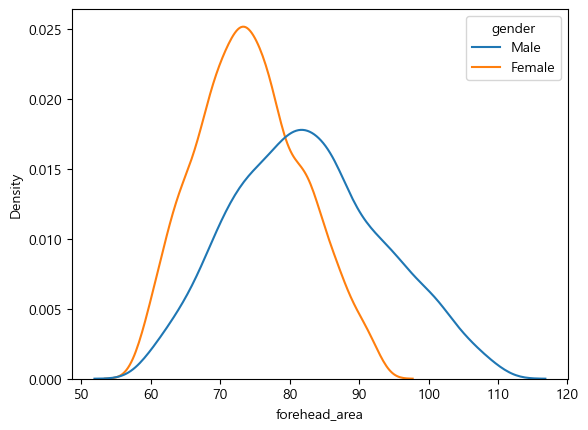

In [35]:
sns.kdeplot(df, x = 'forehead_area', hue = 'gender')

In [37]:
# 분류하기 어려운 케이스 식별
df.loc[(df['nose_var'] == '000') & (df['gender'] =='Male')] # 단 4명만 나온다. 
# '& (df['lips_thin == 1)'으로 lip_thin 추가한다하더라도 의 경우 0,1이 혼재되어 분류불가하다 (머신러닝 : 과적합) - 찾을수 없는 값

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender,nose_var,forehead_area
1738,1,13.7,6.1,0,0,0,0,Male,000,83.57
2031,1,14.8,6.4,0,0,1,0,Male,000,94.72
2406,1,13.6,5.3,0,0,1,0,Male,000,72.08
4286,1,15.4,5.3,0,0,1,0,Male,000,81.62


In [38]:
# 분류하기 어려운 케이스 식별반대케이스 > 코 관련만으로는 어려우나 다른 조건을 결합하여 남/여 구분정확도 올린다
df.loc[(df['nose_var'] == '111') & (df['gender'] =='Female')] # + lips_thin 이 0이고 + forehead_area로 체크

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender,nose_var,forehead_area
472,1,13.0,5.5,1,1,0,1,Female,111,71.50
1070,1,12.7,5.8,1,1,0,1,Female,111,73.66
1420,1,13.8,6.0,1,1,0,1,Female,111,82.80
3626,1,11.4,5.5,1,1,0,1,Female,111,62.70
